# 1.Package Import

In [1]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np

from new_code import data_summary, load_data_into_pds, load_data_into_dict

import pickle

ModuleNotFoundError: No module named 'bmovie_code'

# 2. Global file location (need to specify your own path)

In [2]:
NWB_DIR=r"../nwb_files" #have added data to git folder and added to .gitignore to make retrieval easier theoretically
#BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [3]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    #bids_datadir=BIDS_DIR
)

NameError: name 'gen_table1_subj_info' is not defined

In [ ]:
# nwb_df, bids_df = data_summary.run_summary(NWB_DIR, BIDS_DIR, max_nwb_files=3, max_bids_files_each=5)

# nwb_df.head(), bids_df.head()

# 3. Load labels and data

In [4]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(face_annots)

NameError: name 'pickle' is not defined

In [5]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

NameError: name 'load_data_into_pds' is not defined

In [7]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("../nwb_files/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [8]:
sub_nums = [41]

data = load_data_into_dict.load_multimodal_subjects(
    sub_nums=sub_nums,
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=20000,
    load_fmri=False
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))

NameError: name 'load_data_into_dict' is not defined

## Tucker's PCA

Explained variance: 47.54%


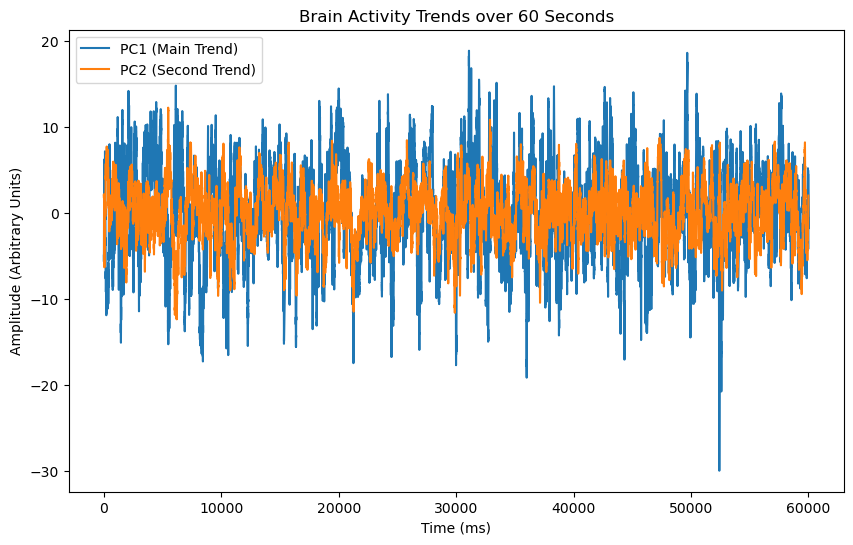

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
#updated for file opening
import pandas as pd
import numpy as np
from pynwb import NWBHDF5IO
#filename will need to be altered to work in this
filename ='../nwb_files/sub-CS41/sub-CS41_ses-P41CSR2_behavior+ecephys.nwb'
io = NWBHDF5IO(filename, 'r')
nwbfile = io.read()
nwbfile
#-----end update
lfp_interface = nwbfile.processing['ecephys'].data_interfaces['LFP_macro']
series_key = list(lfp_interface.electrical_series.keys())[0]
lfp_series = lfp_interface.electrical_series[series_key]
lfp_matrix = lfp_series.data[:60000, :]

scaler = StandardScaler()
lfp_scaled = scaler.fit_transform(lfp_matrix)

pca = PCA(n_components=3)
pca_results = pca.fit_transform(lfp_scaled)

print(f"Explained variance: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(pca_results[:, 0], label='PC1 (Main Trend)')
plt.plot(pca_results[:, 1], label='PC2 (Second Trend)')
plt.title("Brain Activity Trends over 60 Seconds")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (Arbitrary Units)")
plt.legend()
plt.show()


In [ ]:
from sqlalchemy import values


Scene_info=pd.read_csv("../assets/annotations/scenecut_info.csv")
Scene_start_t=Scene_info["shot_start_t"].values
Scene_start_fr=Scene_info["shot_start_fr"].values
Scene_dur=Scene_info["shot_dur_t"].values
Scene_end_t=Scene_start_t[:]+ Scene_dur[:]
Scene_loc=Scene_info["location"].values
sampling_rate = 1000
scene_lfp_window = [None] * (len(Scene_info)-1)
for i in range(len(Scene_info)-1):
    
    start_idx = int((Scene_start_t[i]) * sampling_rate)
    end_idx = int((Scene_end_t[i]) * sampling_rate)
    scene_lfp_window[i] = lfp_series.data[start_idx:end_idx, :]

from sklearn.model_selection import train_test_split as split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA



X_features = [np.std(window, axis=0) for window in scene_lfp_window if window is not None]
X = np.array(X_features)
y = Scene_loc[:len(X)]


from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = split(X_scaled, y, test_size=0.33, random_state=42)


lda_model = LDA(solver='eigen', shrinkage='auto')
lda_model.fit(X_train, y_train)

print("Power-based Training Accuracy:", lda_model.score(X_train, y_train))
print("Power-based Testing Accuracy:", lda_model.score(X_test, y_test))


Power-based Training Accuracy: 0.9180327868852459
Power-based Testing Accuracy: 0.6129032258064516


Dante's PCA (work in progress)

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

X = data[41]["lfp_macro"][:100,:]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.hlines(0.95, 0, len(pca.explained_variance_ratio_), colors='r', linestyles='dashed')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')


import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:1000, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.show()

NameError: name 'data' is not defined